In [3]:
file_path = 'comparacion.xlsx'

# Leer la matriz comparativa para obtener los nombres de las herramientas
df_matriz = pd.read_excel(file_path, sheet_name='Matriz comparativa')

# Las herramientas están en las columnas a partir de la cuarta (índice 3)
tool_names = df_matriz.columns[3:].tolist()
tool_names = [t for t in tool_names if 'AdaptaTuTexto' not in t]
print(f"Tools found: {len(tool_names)}")
print(tool_names)

Tools found: 12
['Lectura Fácil [Referencia]', 'FACILE', 'Placea', 'Asistente de lectura fácil “Antonio Gonzales Crespo”', 'Asistente de lectura fácil “Mark Jonathan Camacho Escatel”: ', 'Gemini 3.1 Pro', 'GPT 5.4 Think', 'Claude Sonnet 4.6', 'deepseek-v3.2', 'SimpleText (ClearText)', 'Modelo_Qwen3.5_9B', 'Asistente Lectura Facilitada "Francisco Javier Alvarez Jimenez"']


In [4]:
# Diccionario para almacenar los checklists de cada herramienta
checklists = {}

i = 1
for tool in tool_names:
    
    sheet_name = str(i)

    try:
        # Leer la hoja numerada correspondiente
        print(f"Loading checklist for tool: {tool} from sheet: {sheet_name}")
        df_sheet = pd.read_excel(file_path, sheet_name=sheet_name)
        
        # Limpiar datos: nos interesan las filas que tienen un ítem de verificación
        # (normalmente hasta la fila 18-19, antes del total)
        df_clean = df_sheet.dropna(subset=['Ítem de Validación'])
        df_clean = df_clean[df_clean['Ítem de Validación'] != 'Total Cumplidos']
        
        # Guardar en el diccionario
        checklists[tool] = df_clean
    except Exception as e:
        print(f"Error cargando la hoja {sheet_name} para la herramienta {tool}: {e}")
    
    if "Mark Jonathan Camacho Escatel" in tool:
        i = 13
    else:
        i += 1
print("Checklists loaded successfully.")


Loading checklist for tool: Lectura Fácil [Referencia] from sheet: 1
Loading checklist for tool: FACILE from sheet: 2
Loading checklist for tool: Placea from sheet: 3
Loading checklist for tool: Asistente de lectura fácil “Antonio Gonzales Crespo” from sheet: 4
Loading checklist for tool: Asistente de lectura fácil “Mark Jonathan Camacho Escatel”:  from sheet: 5
Loading checklist for tool: Gemini 3.1 Pro from sheet: 13
Loading checklist for tool: GPT 5.4 Think from sheet: 14
Loading checklist for tool: Claude Sonnet 4.6 from sheet: 15
Loading checklist for tool: deepseek-v3.2 from sheet: 16
Loading checklist for tool: SimpleText (ClearText) from sheet: 17
Loading checklist for tool: Modelo_Qwen3.5_9B from sheet: 18
Loading checklist for tool: Asistente Lectura Facilitada "Francisco Javier Alvarez Jimenez" from sheet: 19
Checklists loaded successfully.


In [186]:
id_index = -1
print(tool_names[id_index])
checklists[tool_names[id_index]].head()

Asistente Lectura Facilitada "Francisco Javier Alvarez Jimenez"


,Categoría,Epígrafe,Ítem de Validación,Cumple,Observaciones,Evidencia
0,Identificación,Datos del Cedente,"Nombre, DNI/pasaporte y mail",1.0,Identifica plenamente al firmante antes de las...,"""Yo me llamo: ______________________ Mi DNI o ..."
1,Estructura,Multinivel,Dos capas diferenciadas,1.0,Presenta una estructura clara dividida por sec...,"""Información sobre tus datos personales... ¿Qu..."
2,Básica (Capa 1),Título,Identificación clara,1.0,El título define de manera transparente e unív...,"""Autorización para usar imágenes y vídeos"""
3,Básica (Capa 1),Responsable,Identidad,1.0,Especifica claramente en la capa introductoria...,"""Yo autorizo a la Universidad Politécnica de M..."
4,Básica (Capa 1),Finalidad,Fines del tratamiento,1.0,Describe los fines específicos (difusión del p...,"""a usar y difundir las imágenes o vídeos en lo..."


## 2. Data Consolidation

We create a master DataFrame where each row is a checklist item and each column is a tool.

In [5]:
# Obtener la lista base de ítems (usando la primera herramienta como referencia)
base_items = checklists[tool_names[0]][['Categoría', 'Ítem de Validación']].copy()
base_items['Categoría'] = base_items['Categoría'].ffill() # Rellenar categorías vacías

# Crear el DataFrame maestro
df_master = base_items.copy()

for tool in tool_names:
    if tool in checklists:
        # Extraer la columna de cumplimiento
        # 1.0 = SÍ, 0.5 = PARCIAL, 0.0 = NO
        compliance = checklists[tool]['Cumple'].values
        
        # Asegurar que la longitud coincida (por si acaso)
        if len(compliance) == len(df_master):
            values = pd.Series(compliance).apply(lambda x: 0 if x == 0.5 else x)
            df_master[tool] = pd.to_numeric(values, errors='coerce').fillna(0).values
        else:
            # Si hay diferencia, mapeamos por nombre de ítem para seguridad
            print(f"Length mismatch for tool {tool}. Mapping by 'Ítem de Validación'.")
            tool_data = checklists[tool].set_index('Ítem de Validación')['Cumple']
            df_master[tool] = df_master['Ítem de Validación'].map(tool_data)
            df_master[tool] = pd.to_numeric(df_master[tool], errors='coerce').fillna(0)

df_master.head(30)

,Categoría,Ítem de Validación,Lectura Fácil [Referencia],FACILE,Placea,Asistente de lectura fácil “Antonio Gonzales Crespo”,Asistente de lectura fácil “Mark Jonathan Camacho Escatel”:,Gemini 3.1 Pro,GPT 5.4 Think,Claude Sonnet 4.6,deepseek-v3.2,SimpleText (ClearText),Modelo_Qwen3.5_9B,"Asistente Lectura Facilitada ""Francisco Javier Alvarez Jimenez"""
0,Identificación,"Nombre, DNI/pasaporte y mail",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,Estructura,Dos capas diferenciadas,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0
2,Básica (Capa 1),Identificación clara,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Básica (Capa 1),Identidad,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
4,Básica (Capa 1),Fines del tratamiento,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
5,Básica (Capa 1),Base jurídica,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
6,Básica (Capa 1),Cesiones previstas,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
7,Básica (Capa 1),Ejercicio breve,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
8,Garantías,Reglas de uso,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
9,Adicional (Capa 2),Datos completos,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0


## 3. Compliance Analysis

### Total Score by Tool

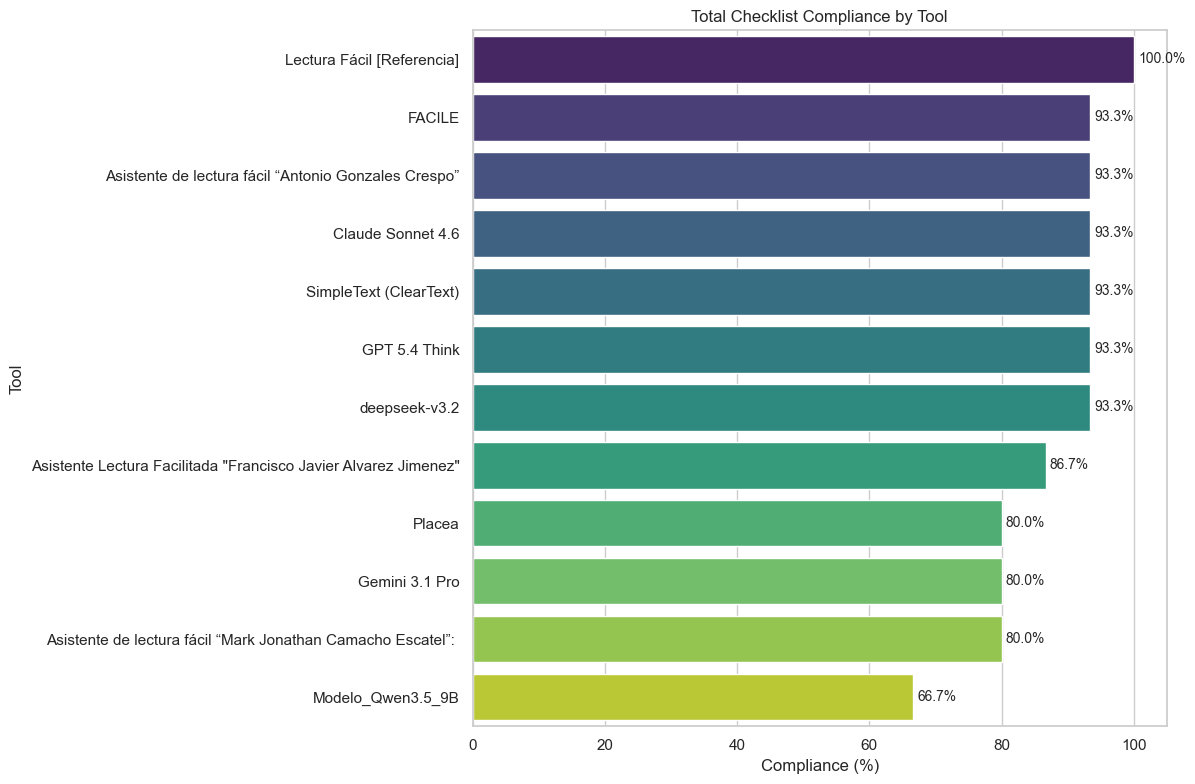

In [7]:
totals = df_master[tool_names].sum().sort_values(ascending=False)
df_totals = pd.DataFrame({'Tool': totals.index, 'Items Fulfilled': totals.values})
df_totals['Compliance (%)'] = (df_totals['Items Fulfilled'] / len(df_master)) * 100

df_totals = df_totals.sort_values('Compliance (%)', ascending=False)

NUM_ITEMS_CHECKLIST = len(df_master)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=df_totals,
    x='Compliance (%)',
    y='Tool',
    hue='Tool',
    dodge=False,
    palette='viridis',
    legend=False
)
plt.title('Total Checklist Compliance by Tool')
plt.xlabel('Compliance (%)')
plt.ylabel('Tool')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

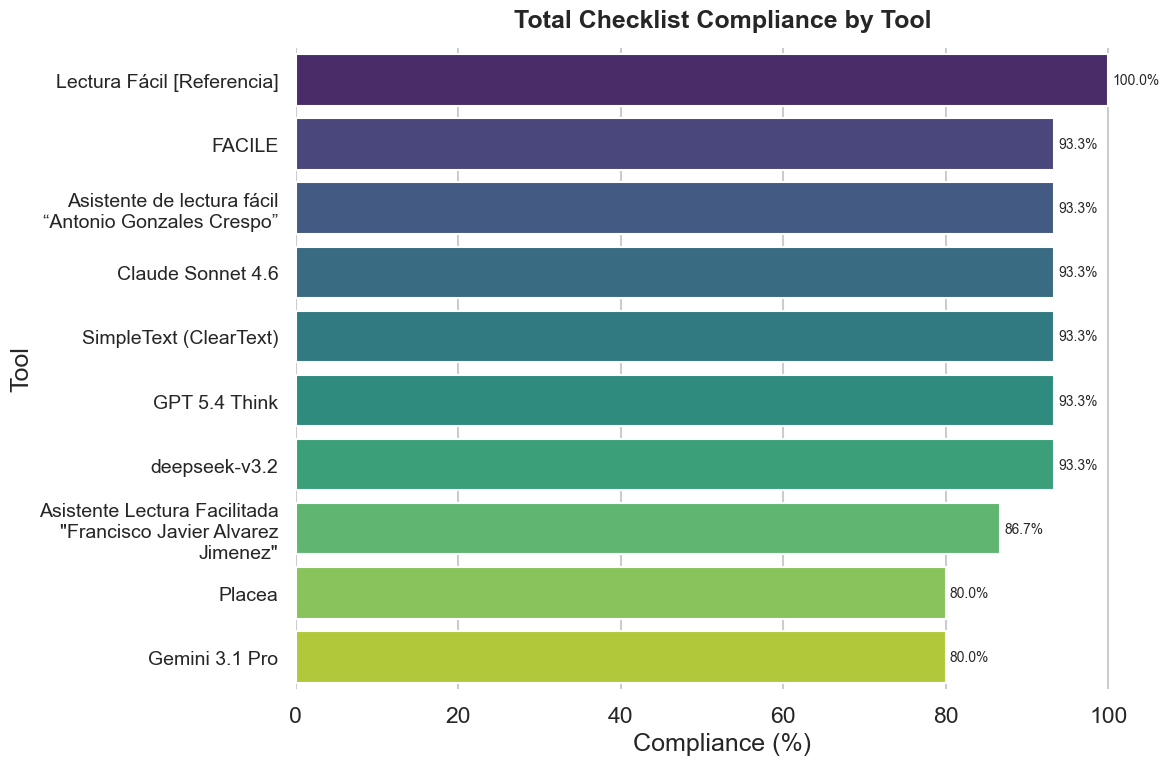

In [8]:
# Versión en porcentajes en una celda nueva
from textwrap import fill

sns.set_theme(style="whitegrid", context="talk")

# Tomar el top 10 y convertirlo a porcentaje sobre el total de incumplimientos
plot_df = df_totals.sort_values("Compliance (%)", ascending=False).copy()
plot_df = plot_df.head(10)

fig, ax = plt.subplots(figsize=(12, 8))

bars = sns.barplot(
    data=plot_df,
    x="Compliance (%)",
    y="Tool",
    hue="Tool",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=ax
)

# Hacer más legibles los nombres del eje Y
wrapped_labels = [fill(label, width=28) for label in plot_df["Tool"]]
ax.set_yticks(ax.get_yticks(), wrapped_labels, fontsize=14)
ax.tick_params(axis="y", labelsize=14)

# Títulos y etiquetas
ax.set_title("Total Checklist Compliance by Tool", pad=15, fontweight="bold")
ax.set_xlabel("Compliance (%)")
ax.set_ylabel("Tool")

# Quitar bordes innecesarios
sns.despine(left=True, bottom=True)

# Etiquetas con porcentaje en cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=10)

plt.tight_layout()
plt.show()

In [189]:
df_totals_checker = totals.to_frame(name='Items Fulfilled')
df_totals_checker["Compliance"] = df_totals_checker['Items Fulfilled'].apply(lambda x: np.round((x/NUM_ITEMS_CHECKLIST)*100,3))
df_totals_checker.set_index(df_totals_checker.index, inplace=True)
df_totals_checker.to_excel("totales_checkers.xlsx", index=True)
display(df_totals_checker)


,Items Fulfilled,Compliance
Lectura Fácil [Referencia],15.0,100.000
FACILE,14.0,93.333
Asistente de lectura fácil “Antonio Gonzales Crespo”,14.0,93.333
Claude Sonnet 4.6,14.0,93.333
SimpleText (ClearText),14.0,93.333
GPT 5.4 Think,14.0,93.333
deepseek-v3.2,14.0,93.333
"Asistente Lectura Facilitada ""Francisco Javier Alvarez Jimenez""",13.0,86.667
Placea,12.0,80.000
Gemini 3.1 Pro,12.0,80.000


### Detailed Compliance Heatmap

This map shows exactly which points each tool fails.

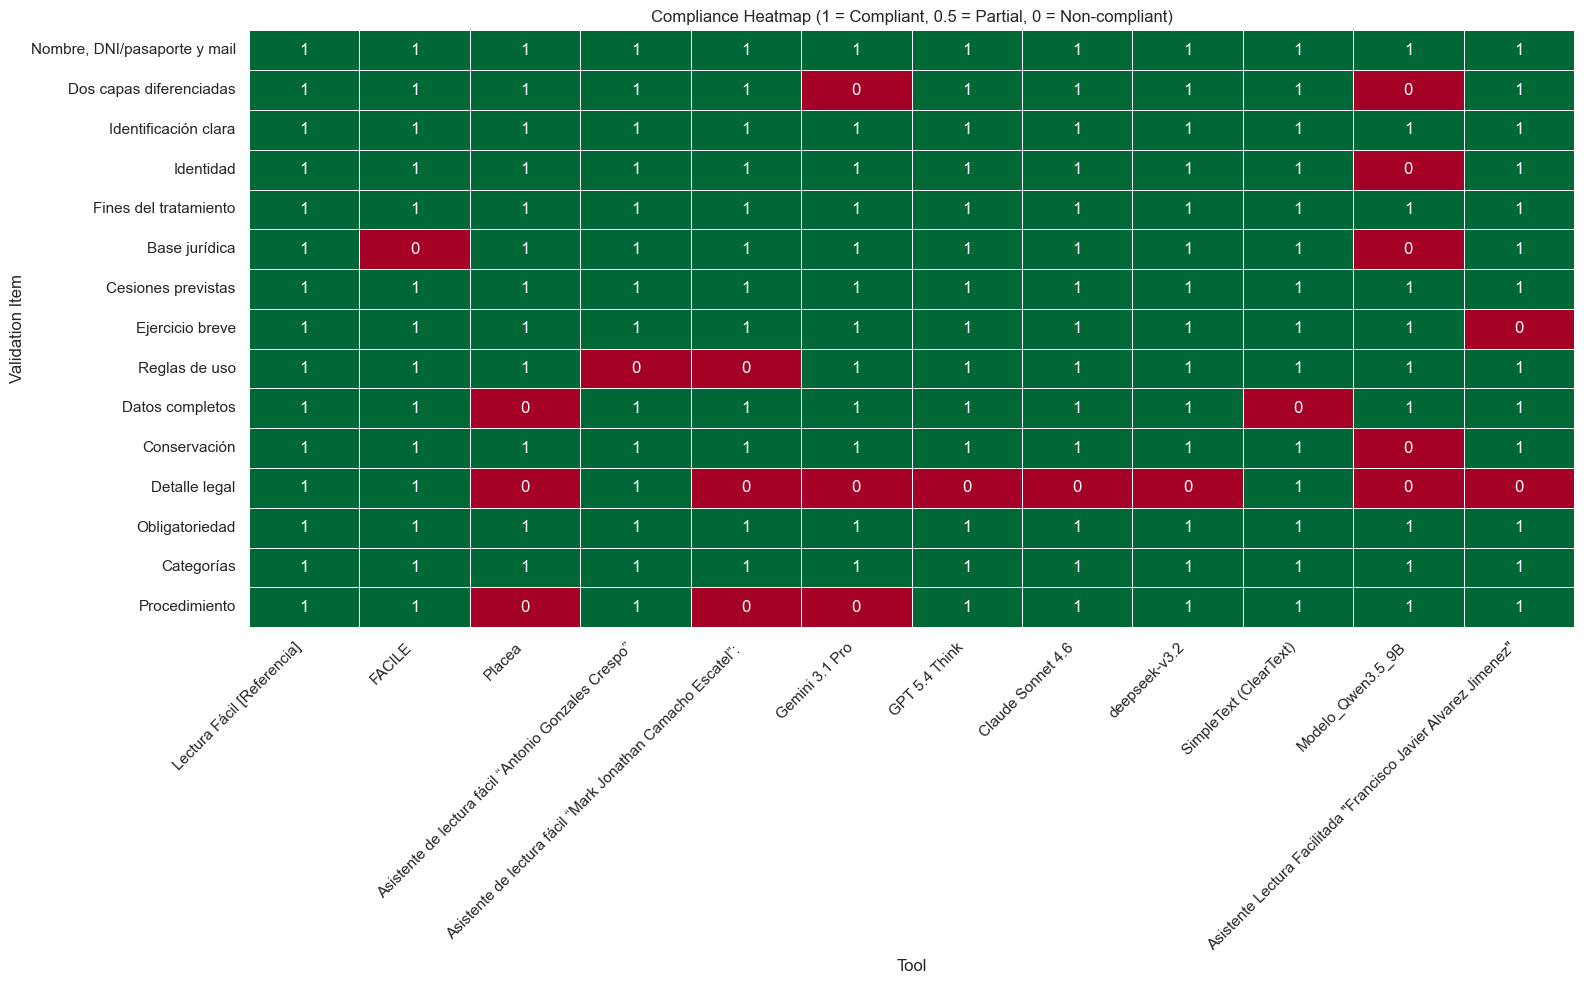

In [190]:
plt.figure(figsize=(16, 10))
heatmap_data = df_master.set_index('Ítem de Validación')[tool_names]
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', cbar=False, linewidths=.5)
plt.title('Compliance Heatmap (1 = Compliant, 0.5 = Partial, 0 = Non-compliant)')
plt.ylabel('Validation Item')
plt.xlabel('Tool')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Most Non-Compliant Items

In [191]:
columns = ["Categoría", "Ítem de Validación",	"Lectura Fácil [Referencia]"]

df_master["Total Non-Compliance"] = df_master.apply(
                                    lambda x: x.drop(columns).count() - x.drop(columns).sum()
                                    , axis=1
                                    )
df_master["Total Non-Compliance %"] = df_master["Total Non-Compliance"].apply(lambda x: np.round((x/len(tool_names))*100,3))
df_master[["Categoría", "Ítem de Validación", "Total Non-Compliance", "Total Non-Compliance %"]].sort_values(by="Total Non-Compliance", ascending = False)

,Categoría,Ítem de Validación,Total Non-Compliance,Total Non-Compliance %
11,Adicional (Capa 2),Detalle legal,8.0,66.667
14,Adicional (Capa 2),Procedimiento,3.0,25.000
1,Estructura,Dos capas diferenciadas,2.0,16.667
9,Adicional (Capa 2),Datos completos,2.0,16.667
8,Garantías,Reglas de uso,2.0,16.667
5,Básica (Capa 1),Base jurídica,2.0,16.667
3,Básica (Capa 1),Identidad,1.0,8.333
10,Adicional (Capa 2),Conservación,1.0,8.333
7,Básica (Capa 1),Ejercicio breve,1.0,8.333
0,Identificación,"Nombre, DNI/pasaporte y mail",0.0,0.000


### Analysis by Category

We group results to see which legal or content sections are most neglected.

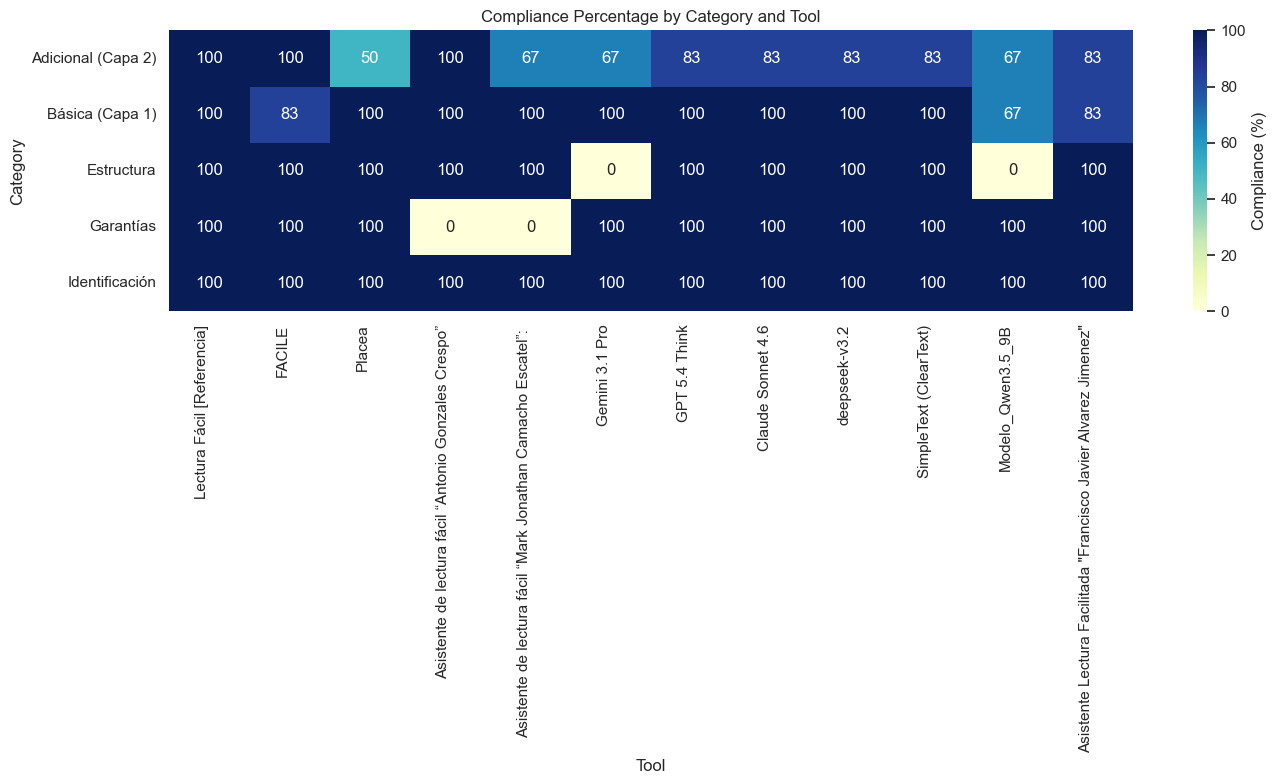

In [192]:
df_cat = df_master.groupby('Categoría')[tool_names].mean() * 100

plt.figure(figsize=(14, 8))
sns.heatmap(df_cat, annot=True, fmt=".0f", cmap='YlGnBu', cbar_kws={'label': 'Compliance (%)'})
plt.title('Compliance Percentage by Category and Tool')
plt.ylabel('Category')
plt.xlabel('Tool')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

## 4. Detailed Summary Tables

The following tables show full compliance, partial compliance, and non-compliance for each tool and item.

In [193]:
# Calcular totales por tipo de cumplimiento
summary_list = []
for tool in tool_names:
    counts = df_master[tool].value_counts()
    summary_list.append({
        'Tool': tool,
        'Compliant (1)': int(counts.get(1.0, 0)),
        'Partial (0.5)': int(counts.get(0.5, 0)),
        'Non-compliant (0)': int(counts.get(0.0, 0))
    })

df_resumen = pd.DataFrame(summary_list)
df_resumen

,Tool,Compliant (1),Partial (0.5),Non-compliant (0)
0,Lectura Fácil [Referencia],15,0,0
1,FACILE,14,0,1
2,Placea,12,0,3
3,Asistente de lectura fácil “Antonio Gonzales C...,14,0,1
4,Asistente de lectura fácil “Mark Jonathan Cama...,12,0,3
5,Gemini 3.1 Pro,12,0,3
6,GPT 5.4 Think,14,0,1
7,Claude Sonnet 4.6,14,0,1
8,deepseek-v3.2,14,0,1
9,SimpleText (ClearText),14,0,1


In [194]:
# Función para dar formato visual
def format_compliance(val):
    if val == 1.0: return 'YES'
    if val == 0.5: return 'PARTIAL'
    return 'NO'

df_visual = df_master.copy()
for tool in tool_names:
    df_visual[tool] = df_visual[tool].apply(format_compliance)

df_visual

,Categoría,Ítem de Validación,Lectura Fácil [Referencia],FACILE,Placea,Asistente de lectura fácil “Antonio Gonzales Crespo”,Asistente de lectura fácil “Mark Jonathan Camacho Escatel”:,Gemini 3.1 Pro,GPT 5.4 Think,Claude Sonnet 4.6,deepseek-v3.2,SimpleText (ClearText),Modelo_Qwen3.5_9B,"Asistente Lectura Facilitada ""Francisco Javier Alvarez Jimenez""",Total Non-Compliance,Total Non-Compliance %
0,Identificación,"Nombre, DNI/pasaporte y mail",YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,0.0,0.000
1,Estructura,Dos capas diferenciadas,YES,YES,YES,YES,YES,NO,YES,YES,YES,YES,NO,YES,2.0,16.667
2,Básica (Capa 1),Identificación clara,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,0.0,0.000
3,Básica (Capa 1),Identidad,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,NO,YES,1.0,8.333
4,Básica (Capa 1),Fines del tratamiento,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,0.0,0.000
5,Básica (Capa 1),Base jurídica,YES,NO,YES,YES,YES,YES,YES,YES,YES,YES,NO,YES,2.0,16.667
6,Básica (Capa 1),Cesiones previstas,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,0.0,0.000
7,Básica (Capa 1),Ejercicio breve,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,NO,1.0,8.333
8,Garantías,Reglas de uso,YES,YES,YES,NO,NO,YES,YES,YES,YES,YES,YES,YES,2.0,16.667
9,Adicional (Capa 2),Datos completos,YES,YES,NO,YES,YES,YES,YES,YES,YES,NO,YES,YES,2.0,16.667


## Table 5.2 — Legal Information Completeness by Tool (Paper Export)

In [195]:
# Tool-to-group mapping for paper table
TOOL_GROUPS = {
    'Placea': 'G1',
    'Asistente de lectura fácil “Antonio Gonzales Crespo”': 'G1',
    'Asistente de lectura fácil “Mark Jonathan Camacho Escatel”: ': 'G1',
    'Asistente Lectura Facilitada "Francisco Javier Alvarez Jimenez"': 'G1',
    'Gemini 3.1 Pro': 'G2',
    'GPT 5.4 Think': 'G2',
    'Claude Sonnet 4.6': 'G2',
    'deepseek-v3.2': 'G2',
    'FACILE': 'G3',
    'SimpleText (ClearText)': 'G3',
    'Modelo_Qwen3.5_9B': 'G3',
    'Lectura Fácil [Referencia]': 'Gold',
}

table_5_2 = df_totals_checker.copy().reset_index()
table_5_2.columns = ['Tool', 'Items Fulfilled', 'Compliance (%)']
table_5_2['Group'] = table_5_2['Tool'].map(TOOL_GROUPS)

# Sort: Gold first, then by compliance descending, excluding AdaptaTuTexto
mask_valid = table_5_2['Tool'].map(lambda t: t in TOOL_GROUPS)
table_5_2 = table_5_2[mask_valid].sort_values(
    ['Group', 'Compliance (%)'], ascending=[True, False]
).reset_index(drop=True)

# Reorder columns
table_5_2 = table_5_2[['Group', 'Tool', 'Items Fulfilled', 'Compliance (%)']]
display(table_5_2)

# Export
table_5_2.to_excel('table_5_2_checklist_compliance.xlsx', index=False)
print("Saved: table_5_2_checklist_compliance.xlsx")


,Group,Tool,Items Fulfilled,Compliance (%)
0,G1,Asistente de lectura fácil “Antonio Gonzales C...,14.0,93.333
1,G1,"Asistente Lectura Facilitada ""Francisco Javier...",13.0,86.667
2,G1,Placea,12.0,80.000
3,G1,Asistente de lectura fácil “Mark Jonathan Cama...,12.0,80.000
4,G2,Claude Sonnet 4.6,14.0,93.333
5,G2,GPT 5.4 Think,14.0,93.333
6,G2,deepseek-v3.2,14.0,93.333
7,G2,Gemini 3.1 Pro,12.0,80.000
8,G3,FACILE,14.0,93.333
9,G3,SimpleText (ClearText),14.0,93.333


Saved: table_5_2_checklist_compliance.xlsx


C:\Users\prestamo_admin\AppData\Local\Temp\ipykernel_26328\3187930789.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


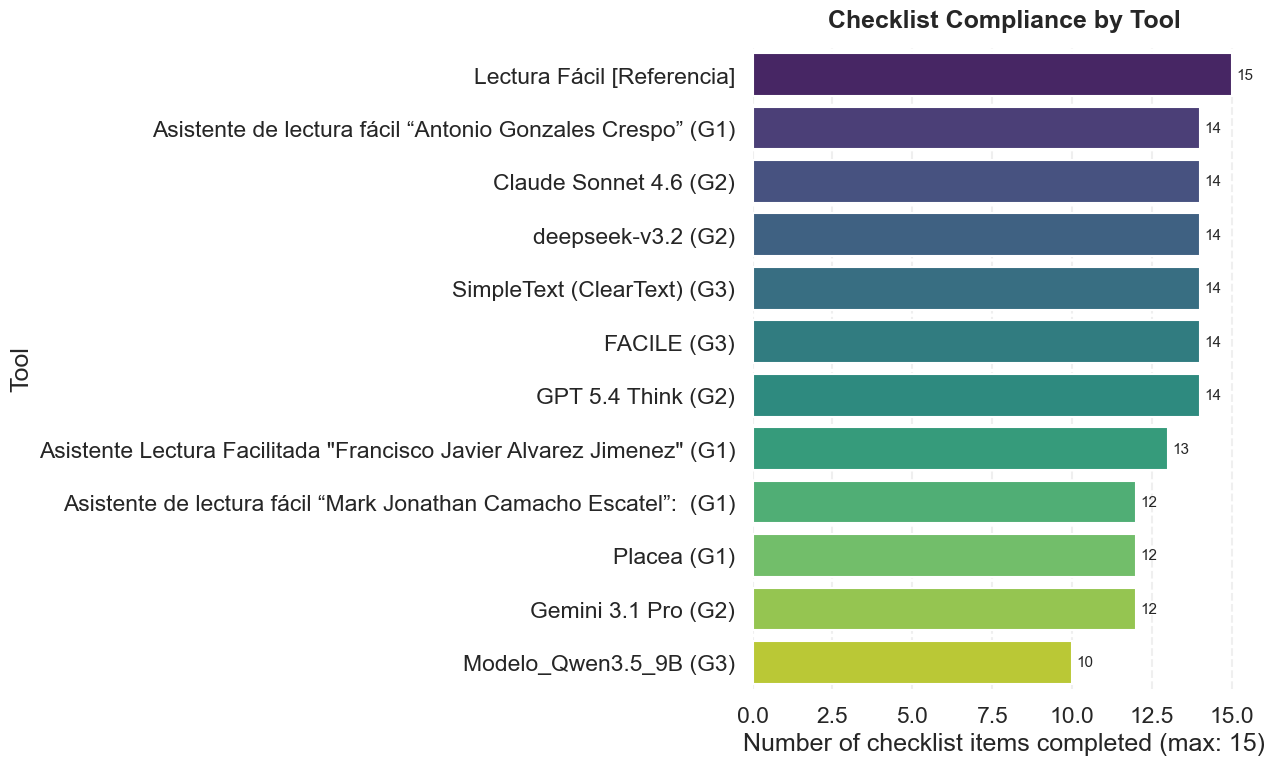

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo más limpio
sns.set_theme(style="whitegrid", context="talk")

# Cargar y ordenar
table_5_2_graph = pd.read_excel("table_5_2_checklist_compliance.xlsx", index_col=None)
table_5_2_graph["Tool"] = table_5_2_graph.apply(lambda x: f"{x['Tool']} ({x['Group']})" if x['Group'] != 'Gold' else x['Tool'], axis=1)
table_5_2_graph = table_5_2_graph.sort_values(by="Items Fulfilled", ascending=False)

NUM_ITEMS_CHECKLIST = len(df_master)

fig, ax = plt.subplots(figsize=(13, 8))

sns.barplot(
    data=table_5_2_graph,
    x="Items Fulfilled",
    y="Tool",
    palette="viridis",
    ax=ax
)

# Título y ejes
ax.set_title("Checklist Compliance by Tool", pad=15, fontweight="bold")
ax.set_xlabel(f"Number of checklist items completed (max: {NUM_ITEMS_CHECKLIST})")
ax.set_ylabel("Tool")

# Mejorar legibilidad
ax.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)

# Etiquetas con valores en cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=11)

# Guardar en PNG
fig.savefig("checklist_compliance.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

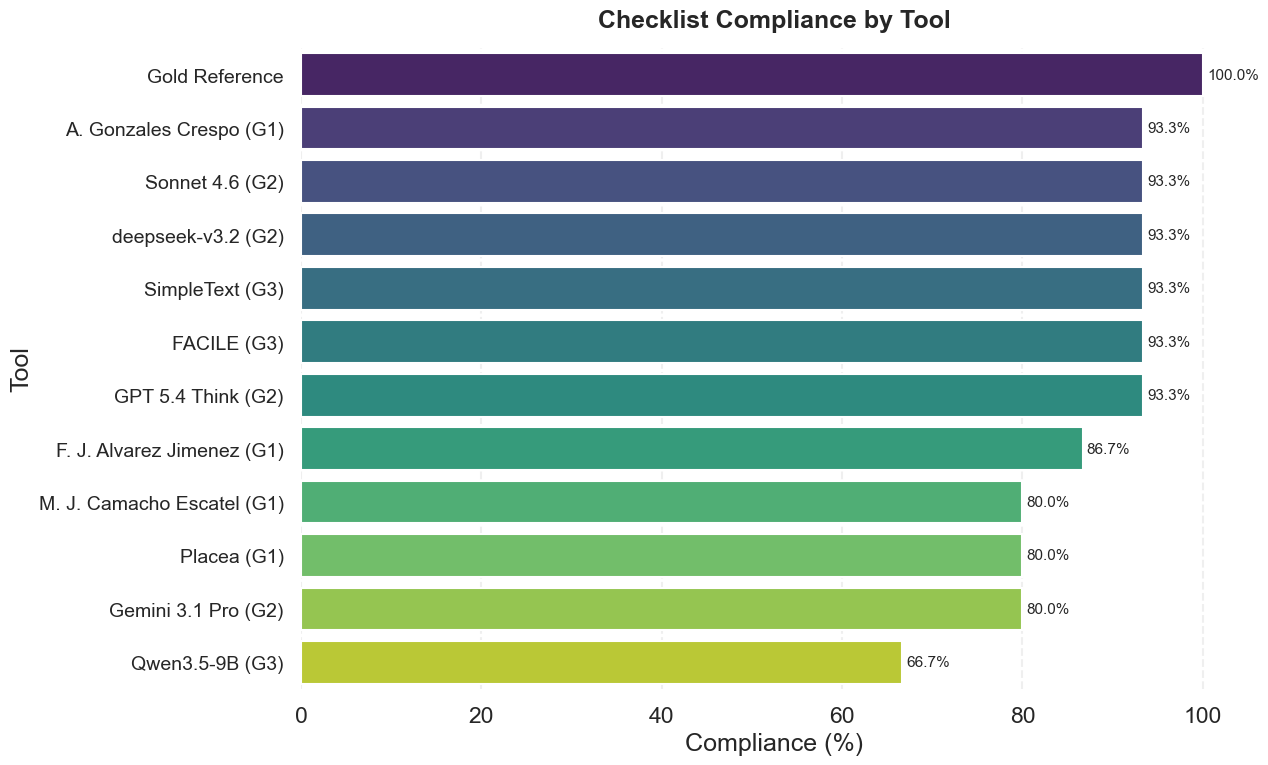

In [11]:
# Versión mejorada en porcentajes con columna nueva
from textwrap import fill

sns.set_theme(style="whitegrid", context="talk")

# Cargar y preparar datos
table_5_2_graph = pd.read_excel("table_5_2_checklist_compliance_change_names.xlsx", index_col=None)
table_5_2_graph["Tool"] = table_5_2_graph.apply(
    lambda x: f"{x['Tool']} ({x['Group']})" if x['Group'] != 'Gold' else x['Tool'],
    axis=1
)

# Nueva columna en porcentaje
NUM_ITEMS_CHECKLIST = len(df_master)
table_5_2_graph["Compliance (%)"] = (table_5_2_graph["Items Fulfilled"] / NUM_ITEMS_CHECKLIST) * 100

# Ordenar por porcentaje y quedarnos con el top visual
table_5_2_graph = table_5_2_graph.sort_values(by="Compliance (%)", ascending=False)

fig, ax = plt.subplots(figsize=(13, 8))

sns.barplot(
    data=table_5_2_graph,
    x="Compliance (%)",
    y="Tool",
    hue="Tool",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=ax
)

# Hacer más legibles los nombres largos del eje Y
wrapped_labels = [fill(label, width=30) for label in table_5_2_graph["Tool"]]
ax.set_yticks(ax.get_yticks(), wrapped_labels, fontsize=14)
ax.tick_params(axis="y", labelsize=14)

# Título y ejes
ax.set_title("Checklist Compliance by Tool", pad=15, fontweight="bold")
ax.set_xlabel("Compliance (%)")
ax.set_ylabel("Tool")

# Mejorar legibilidad
ax.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)

# Etiquetas con valores en cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=11)

# Guardar en PNG
fig.savefig("checklist_compliance_percentage.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()